# Preprocesamiento de Dataset

Este notebook documenta el proceso completo de limpieza, transformación y preparación del dataset con indicadores educativos y económicos por provincia del Perú.

El objetivo final es construir un dataset listo para entrenar un modelo de Machine Learning que clasifique provincias según su **cuartil de desempeño educativo (CUARTIL_2024)**.

El flujo de trabajo sigue estos pasos:
1. Carga del dataset desde Google Drive
2. Revisión y limpieza de valores nulos
3. Análisis y tratamiento de valores atípicos
4. Codificación de variables categóricas (One-Hot Encoding)
5. Transformación de la variable objetivo
6. Análisis y eliminación de variables correlacionadas
7. Exportación del dataset preprocesado

## 1. Carga del Dataset

Este bloque hace tres cosas:

a) Montar Google Drive y cargar el archivo desde nuestra carpeta de trabajo.También se puede leer desde el mismo google colab

b) Ver las primeras filas (`df.head()`), para ver que los datos se cargaron correctamente

c) Revisar la estructura técnica (`df.info()`)

d) Contar los valores nulos (`df.isnull().sum()`)

In [ ]:
import pandas as pd

from google.colab import drive
#drive.mount('/content/drive')
#path = '/content/drive/MyDrive/dataset_final.csv'
#df = pd.read_csv(path, delimiter=',')
df = pd.read_csv('dataset_final.csv')

print("--- Primeras 5 filas del dataset ---")
display(df.head())

print("\n--- Información técnica del dataset ---")
df.info()

print("\n--- Cantidad de valores nulos por columna ---")
print(df.isnull().sum())


--- Primeras 5 filas del dataset ---


,REGION,PROVINCIA,LECT_EN INICIO_2016,LECT_EN PROCESO_2016,LECT_PREVIO AL INICIO_2016,LECT_SATISFACTORIO_2016,MAT_EN INICIO_2016,MAT_EN PROCESO_2016,MAT_PREVIO AL INICIO_2016,MAT_SATISFACTORIO_2016,...,MAT_SATISFACTORIO_2018,MEDIDA PROMEDIO COMPRENSION LECTORA_2018,MEDIDA PROMEDIO MATEMATICA_2018,VAB_Administración_Pública_y_Defensa_2016,VAB_Administración_Pública_y_Defensa_2018,VAB_Electricidad_Gas_y_Agua_2016,VAB_Electricidad_Gas_y_Agua_2018,VAB_Telecom_y_Otros_Serv_de_Información_2016,VAB_Telecom_y_Otros_Serv_de_Información_2018,CUARTIL_2024
0,AMAZONAS,BAGUA,41.933333,24.816667,15.650000,17.566667,27.266667,31.983333,20.700000,20.016667,...,16.940000,455.400000,454.600000,280083.0,302870.0,32680.0,36549.0,54385.0,63345.0,Q3
1,AMAZONAS,BONGARÁ,39.262500,32.462500,9.987500,18.275000,28.525000,41.600000,17.337500,12.562500,...,35.175000,476.250000,477.250000,280083.0,302870.0,32680.0,36549.0,54385.0,63345.0,Q1
2,AMAZONAS,CHACHAPOYAS,29.807143,34.342857,7.107143,28.757143,19.500000,46.628571,11.757143,22.128571,...,30.820000,486.666667,488.133333,280083.0,302870.0,32680.0,36549.0,54385.0,63345.0,Q1
3,AMAZONAS,CONDORCANQUI,34.150000,11.750000,45.300000,8.800000,22.350000,26.600000,47.950000,3.050000,...,0.000000,314.000000,291.500000,280083.0,302870.0,32680.0,36549.0,54385.0,63345.0,Q4
4,AMAZONAS,LUYA,26.976190,39.457143,8.214286,25.347619,20.819048,44.242857,7.876190,27.033333,...,29.554545,472.454545,478.590909,280083.0,302870.0,32680.0,36549.0,54385.0,63345.0,Q1



--- Información técnica del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 29 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   REGION                                        196 non-null    object 
 1   PROVINCIA                                     196 non-null    object 
 2   LECT_EN INICIO_2016                           196 non-null    float64
 3   LECT_EN PROCESO_2016                          196 non-null    float64
 4   LECT_PREVIO AL INICIO_2016                    196 non-null    float64
 5   LECT_SATISFACTORIO_2016                       196 non-null    float64
 6   MAT_EN INICIO_2016                            196 non-null    float64
 7   MAT_EN PROCESO_2016                           196 non-null    float64
 8   MAT_PREVIO AL INICIO_2016                     196 non-null    float64
 9   MAT_SATISFACTORIO_2016  

## 2. Limpieza de Valores Nulos

Tras el diagnóstico inicial, encontramos **1 valor nulo** en el dataset. En este paso decidimos eliminarlo.

- **`df.dropna(inplace=True)`** → Elimina cualquier fila que tenga al menos un campo vacío. El parámetro `inplace=True` significa que el cambio se aplica directamente sobre el DataFrame, sin necesidad de crear uno nuevo.

- **`df.isnull().sum()`** → Lo ejecutamos por segunda vez para **verificar** que ya no queda ningún nulo.

- **`df.shape`** → Nos confirma el tamaño final del dataset para saber con cuántos registros continuamos trabajando.

> **Nota:** Adicionalmente, se excluye la provincia del **Callao** porque, al ser una Provincia Constitucional, el INEI no reporta sus indicadores de la misma forma que las demás regiones, lo que haría que ese dato sea incomparable con el resto.

In [ ]:
df.dropna(inplace=True)

print("--- Nueva cantidad de valores nulos ---")
print(df.isnull().sum())

print("\n--- Tamaño actual del dataset (filas, columnas) ---")
print(df.shape)


--- Nueva cantidad de valores nulos ---
REGION                                          0
PROVINCIA                                       0
LECT_EN INICIO_2016                             0
LECT_EN PROCESO_2016                            0
LECT_PREVIO AL INICIO_2016                      0
LECT_SATISFACTORIO_2016                         0
MAT_EN INICIO_2016                              0
MAT_EN PROCESO_2016                             0
MAT_PREVIO AL INICIO_2016                       0
MAT_SATISFACTORIO_2016                          0
MEDIDA PROMEDIO COMPRENSION LECTORA_2016        0
MEDIDA PROMEDIO MATEMATICA_2016                 0
LECT_EN INICIO_2018                             0
LECT_EN PROCESO_2018                            0
LECT_PREVIO AL INICIO_2018                      0
LECT_SATISFACTORIO_2018                         0
MAT_EN INICIO_2018                              0
MAT_EN PROCESO_2018                             0
MAT_PREVIO AL INICIO_2018                       0
MAT_SATISF

## 3. Detección de Valores Atípicos

Usamos dos herramientas para identificar si hay datos extremos que distorsionen el modelo:

- **`df.describe()`** → Muestra un resumen estadístico (media, mínimo, máximo, percentiles) de todas las columnas numéricas.

> En este caso, decidimos **no eliminar** datos atípicos, sino escalar los datos.

In [ ]:
import matplotlib.pyplot as plt

print("--- Resumen estadístico ---")
display(df.describe())

--- Resumen estadístico ---


,LECT_EN INICIO_2016,LECT_EN PROCESO_2016,LECT_PREVIO AL INICIO_2016,LECT_SATISFACTORIO_2016,MAT_EN INICIO_2016,MAT_EN PROCESO_2016,MAT_PREVIO AL INICIO_2016,MAT_SATISFACTORIO_2016,MEDIDA PROMEDIO COMPRENSION LECTORA_2016,MEDIDA PROMEDIO MATEMATICA_2016,...,MAT_PREVIO AL INICIO_2018,MAT_SATISFACTORIO_2018,MEDIDA PROMEDIO COMPRENSION LECTORA_2018,MEDIDA PROMEDIO MATEMATICA_2018,VAB_Administración_Pública_y_Defensa_2016,VAB_Administración_Pública_y_Defensa_2018,VAB_Electricidad_Gas_y_Agua_2016,VAB_Electricidad_Gas_y_Agua_2018,VAB_Telecom_y_Otros_Serv_de_Información_2016,VAB_Telecom_y_Otros_Serv_de_Información_2018
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,1.950000e+02,1.950000e+02,1.950000e+02,1.950000e+02,1.950000e+02,1.950000e+02
mean,32.941069,29.836656,17.566786,19.656172,26.616738,36.249838,18.690427,18.446310,445.722579,441.687626,...,15.269626,22.703270,450.247870,455.155666,1.256486e+06,1.358665e+06,4.570555e+05,4.850824e+05,1.039802e+06,1.183949e+06
std,7.468068,6.791325,11.872563,10.985930,6.529330,8.446178,13.172250,10.823196,35.375467,39.681975,...,13.092107,11.279559,36.227285,40.334365,2.629441e+06,2.798204e+06,1.075312e+06,1.059461e+06,2.878559e+06,3.233719e+06
min,0.000000,8.820000,0.000000,0.000000,2.075000,3.600000,0.000000,0.000000,340.000000,329.000000,...,0.000000,0.000000,314.000000,291.500000,1.037240e+05,1.129220e+05,1.799400e+04,2.022600e+04,2.757200e+04,3.126300e+04
25%,29.210714,26.150000,8.882143,12.018056,22.864583,32.313333,9.227097,11.170000,424.500000,418.600000,...,7.699476,15.785965,433.823077,437.708333,4.423780e+05,4.929310e+05,6.846300e+04,7.363600e+04,1.882890e+05,2.156190e+05
50%,34.666667,31.050000,15.905263,17.126667,27.266667,38.566667,15.750000,16.487500,443.700000,442.083333,...,11.452941,21.300000,452.650000,459.777778,7.075600e+05,7.564530e+05,1.453620e+05,2.185440e+05,3.399390e+05,3.929960e+05
75%,37.661667,34.458442,21.525000,25.591667,30.702083,42.351923,23.500000,23.502621,469.911111,465.325000,...,18.385000,29.527273,474.208333,480.812500,8.621330e+05,9.498130e+05,3.238570e+05,3.640120e+05,4.908490e+05,5.790760e+05
max,49.320000,47.880000,83.300000,66.675000,43.285714,49.500000,67.900000,63.550000,553.250000,569.000000,...,92.550000,75.200000,567.200000,605.200000,1.248246e+07,1.330209e+07,5.007363e+06,4.933879e+06,1.333689e+07,1.499197e+07


## 4. Análisis de One-Hot Label-encoding o Category

Antes de aplicar One-Hot Encoding, analizamos cuántos valores únicos tienen
**REGIÓN** y **PROVINCIA** para estimar el impacto en el número de columnas del dataset.

Luego, calculamos el impacto de realizar el one-hot porque codificar ambas variables directamente dispararía demasiado el número de columnas,
por lo que este análisis nos llevó a tomar una decisión diferente para cada una:
convertir PROVINCIA en índice y aplicar One-Hot Encoding solo a REGIÓN.

In [ ]:

# Ver únicos
unicos_region = df['REGION'].nunique()
unicos_provincia = df['PROVINCIA'].nunique()

print(f"Valores únicos en Región: {unicos_region}")
print(f"Valores únicos en Provincia: {unicos_provincia}")

# Calcular el impacto
columnas_actuales = df.shape[1]
columnas_nuevas = columnas_actuales - 2 + unicos_region + unicos_provincia

print(f"\nSi aplicas One-Hot Encoding a ambas:")
print(f"Tu dataset pasará de {columnas_actuales} columnas a {columnas_nuevas} columnas.")


Valores únicos en Región: 24
Valores únicos en Provincia: 195

Si aplicas One-Hot Encoding a ambas:
Tu dataset pasará de 29 columnas a 246 columnas.


## 5. Transformación de Variables Categóricas

Dado el análisis anterior, tomamos decisiones distintas para cada variable:

- **PROVINCIA** se convirtió en el índice del DataFrame. Así la mantenemos
como referencia sin que el modelo la use como variable de entrenamiento.
- **REGIÓN** se codificó con One-Hot Encoding usando `pd.get_dummies()`,
generando una columna binaria por cada región. Se usó `drop_first=True`
para evitar multicolinealidad, eliminando una región que queda implícita en las demás.

Finalmente se imprime el nuevo tamaño y las 5 primeras filas del dataset para verificar los cambios.

In [ ]:
# 1. Convertir 'Provincia' en el índice
df.set_index('PROVINCIA', inplace=True)
print("--- 'Provincia' ahora es el índice (no se usará para entrenar) ---")

# 2. Aplicar One-Hot Encoding a la variable 'Region'
df = pd.get_dummies(df, columns=['REGION'], drop_first=True)
print("\n--- One-Hot Encoding aplicado a 'Region' ---")

print("\n--- Tamaño del dataset después de las transformaciones ---")
print(df.shape)
display(df.head())


--- 'Provincia' ahora es el índice (no se usará para entrenar) ---

--- One-Hot Encoding aplicado a 'Region' ---

--- Tamaño del dataset después de las transformaciones ---
(195, 50)


,LECT_EN INICIO_2016,LECT_EN PROCESO_2016,LECT_PREVIO AL INICIO_2016,LECT_SATISFACTORIO_2016,MAT_EN INICIO_2016,MAT_EN PROCESO_2016,MAT_PREVIO AL INICIO_2016,MAT_SATISFACTORIO_2016,MEDIDA PROMEDIO COMPRENSION LECTORA_2016,MEDIDA PROMEDIO MATEMATICA_2016,...,REGION_LORETO,REGION_MADRE DE DIOS,REGION_MOQUEGUA,REGION_PASCO,REGION_PIURA,REGION_PUNO,REGION_SAN MARTIN,REGION_TACNA,REGION_TUMBES,REGION_UCAYALI
PROVINCIA,,,,,,,,,,,,,,,,,,,,,
BAGUA,41.933333,24.816667,15.650000,17.566667,27.266667,31.983333,20.700000,20.016667,436.500000,439.666667,...,False,False,False,False,False,False,False,False,False,False
BONGARÁ,39.262500,32.462500,9.987500,18.275000,28.525000,41.600000,17.337500,12.562500,451.500000,433.625000,...,False,False,False,False,False,False,False,False,False,False
CHACHAPOYAS,29.807143,34.342857,7.107143,28.757143,19.500000,46.628571,11.757143,22.128571,474.571429,464.428571,...,False,False,False,False,False,False,False,False,False,False
CONDORCANQUI,34.150000,11.750000,45.300000,8.800000,22.350000,26.600000,47.950000,3.050000,383.000000,371.000000,...,False,False,False,False,False,False,False,False,False,False
LUYA,26.976190,39.457143,8.214286,25.347619,20.819048,44.242857,7.876190,27.033333,476.000000,474.047619,...,False,False,False,False,False,False,False,False,False,False


## 6. Transformación de la Variable Objetivo (CUARTIL_2024)

La columna CUARTIL_2024 contenía valores de texto (Q1, Q2, Q3, Q4),
por lo que se mapearon manualmente a números (0, 1, 2, 3) respetando su orden natural.

Luego se graficó la distribución de provincias por cuartil para verificar
si las clases están balanceadas, lo cual es importante para que el modelo
no aprenda a predecir siempre el cuartil más frecuente.

--- Cuartiles transformados a formato numérico ---

--- Distribución de provincias por Cuartil ---
CUARTIL_2024
0    59
1    47
2    41
3    48
Name: count, dtype: int64


/tmp/ipykernel_1605/3830330363.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CUARTIL_2024'] = df['CUARTIL_2024'].replace(mapeo_cuartiles)


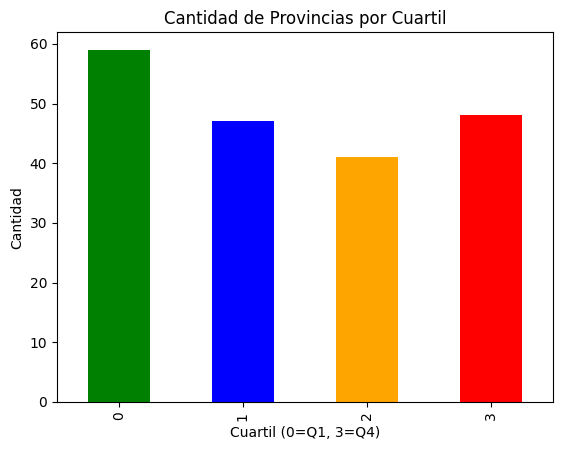

In [ ]:
# 1. Transformar los cuartiles a números
mapeo_cuartiles = {'Q1': 0, 'Q2': 1, 'Q3': 2, 'Q4': 3}
df['CUARTIL_2024'] = df['CUARTIL_2024'].replace(mapeo_cuartiles)

print("--- Cuartiles transformados a formato numérico ---")

# 2. Revisar si hay desbalance de clases
print("\n--- Distribución de provincias por Cuartil ---")
distribucion = df['CUARTIL_2024'].value_counts().sort_index()
print(distribucion)

import matplotlib.pyplot as plt
distribucion.plot(kind='bar', color=['green', 'blue', 'orange', 'red'])
plt.title('Cantidad de Provincias por Cuartil')
plt.xlabel('Cuartil (0=Q1, 3=Q4)')
plt.ylabel('Cantidad')
plt.show()


## 7. Análisis de Correlación entre Variables

Para evitar que el modelo reciba información redundante, analizamos qué tan
correlacionadas están las variables entre sí. Variables muy correlacionadas
aportan básicamente lo mismo y pueden perjudicar el rendimiento del modelo.

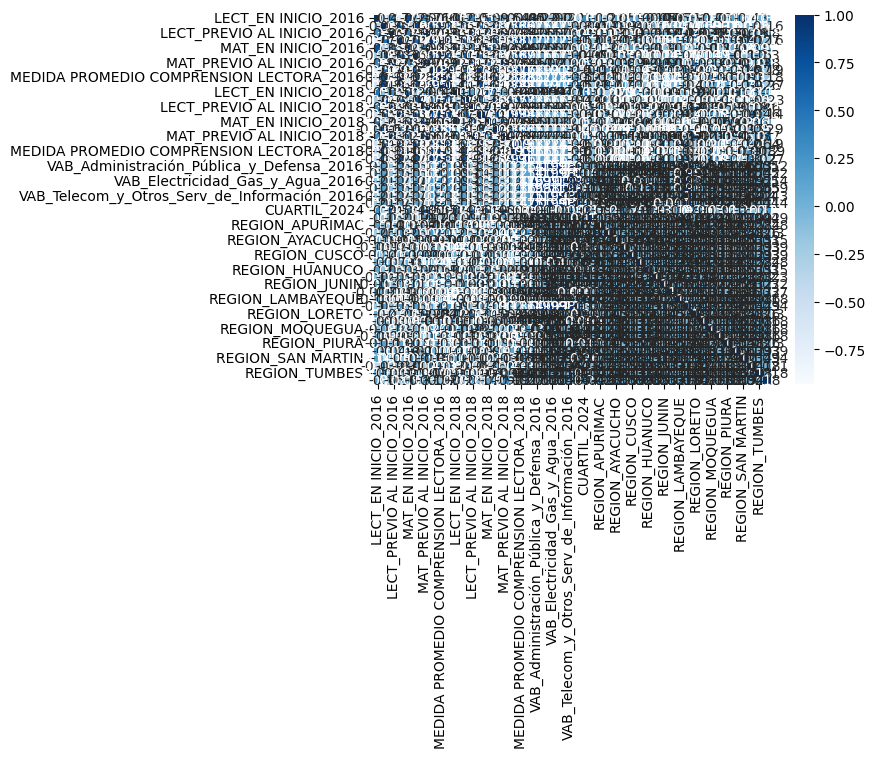

In [ ]:
import seaborn as sns

df_corr = df.corr()
sns.heatmap(df_corr, annot=True, cmap='Blues')
plt.show()

El heatmap general es útil visualmente pero difícil de leer con muchas variables.
Por eso generamos una tabla que lista todos los pares de variables con correlación
mayor o igual a 0.9, ordenados de mayor a menor. Ese umbral de 0.9 fue el criterio
que usamos para considerar que dos variables son demasiado similares.

In [ ]:
import numpy as np
import pandas as pd

corr_matrix = df.corr(numeric_only=True)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = upper_tri.unstack().dropna().reset_index()
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# Filtrar por el umbral de 0.9
altas_correlaciones = corr_pairs[corr_pairs['Correlacion'].abs() >= 0.9]

# Ordenar los resultados de mayor a menor fuerza
altas_correlaciones = altas_correlaciones.sort_values(by='Correlacion', key=abs, ascending=False)

print(f"Se encontraron {len(altas_correlaciones)} pares de variables con correlación >= 0.9:")
display(altas_correlaciones)

Se encontraron 37 pares de variables con correlación >= 0.9:


,Variable_1,Variable_2,Correlacion
230,VAB_Administración_Pública_y_Defensa_2018,VAB_Administración_Pública_y_Defensa_2016,0.999983
324,VAB_Telecom_y_Otros_Serv_de_Información_2018,VAB_Telecom_y_Otros_Serv_de_Información_2016,0.999969
296,VAB_Telecom_y_Otros_Serv_de_Información_2016,VAB_Administración_Pública_y_Defensa_2016,0.998344
320,VAB_Telecom_y_Otros_Serv_de_Información_2018,VAB_Administración_Pública_y_Defensa_2016,0.998218
297,VAB_Telecom_y_Otros_Serv_de_Información_2016,VAB_Administración_Pública_y_Defensa_2018,0.998218
321,VAB_Telecom_y_Otros_Serv_de_Información_2018,VAB_Administración_Pública_y_Defensa_2018,0.998089
275,VAB_Electricidad_Gas_y_Agua_2018,VAB_Electricidad_Gas_y_Agua_2016,0.997120
765,REGION_LIMA,VAB_Telecom_y_Otros_Serv_de_Información_2016,0.995767
766,REGION_LIMA,VAB_Telecom_y_Otros_Serv_de_Información_2018,0.995313
761,REGION_LIMA,VAB_Administración_Pública_y_Defensa_2016,0.995156


Con los pares identificados, generamos un segundo heatmap mostrando únicamente
las variables con alta correlación, para visualizar con más claridad cuáles
son las candidatas a eliminar en el siguiente paso.

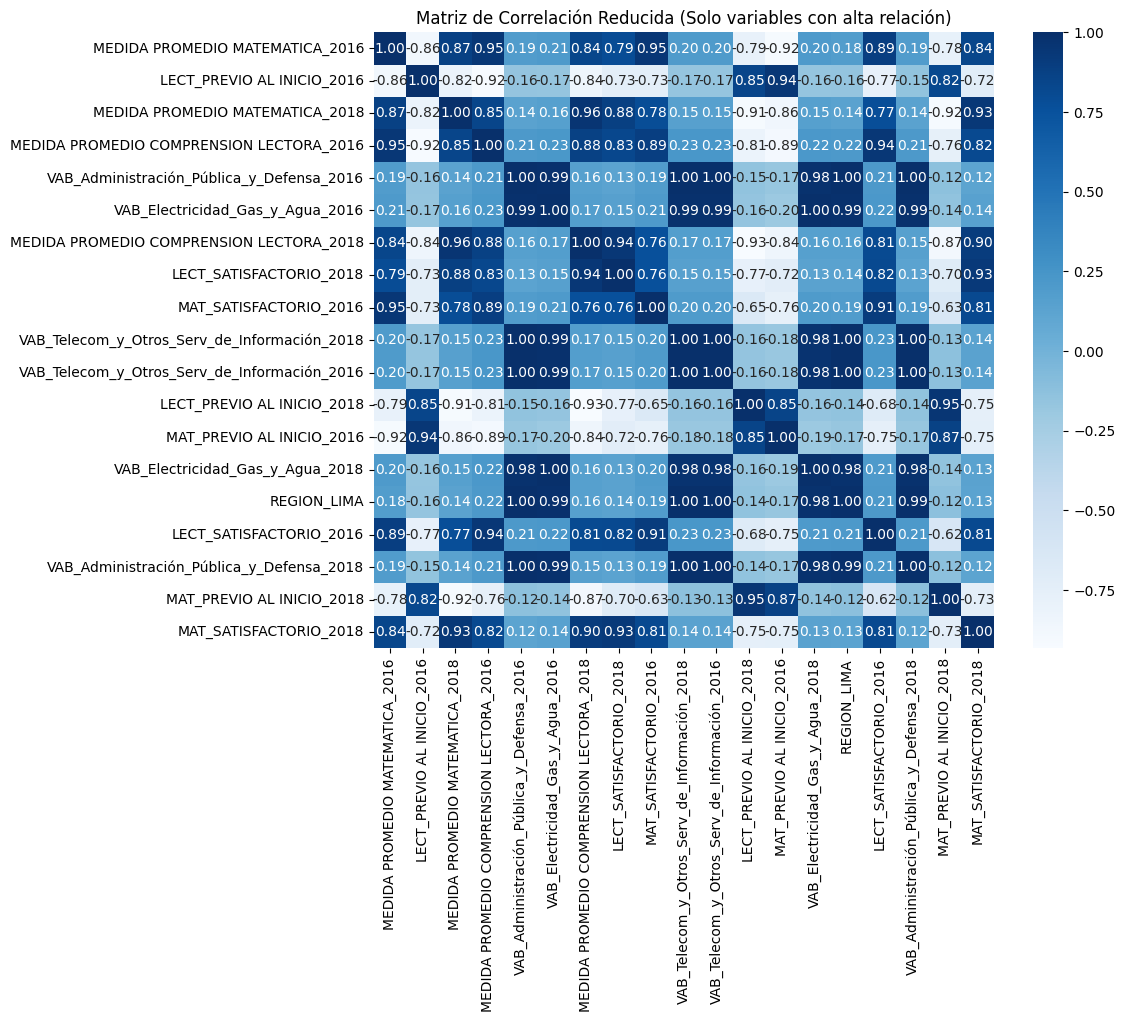

In [ ]:
if not altas_correlaciones.empty:

    columnas_clave = list(set(altas_correlaciones['Variable_1'].tolist() + altas_correlaciones['Variable_2'].tolist()))

    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 8))
    sns.heatmap(df[columnas_clave].corr(), annot=True, cmap='Blues', fmt=".2f")
    plt.title("Matriz de Correlación Reducida (Solo variables con alta relación)")
    plt.show()
else:
    print("No hay suficientes variables con correlación >= 0.9 para graficar.")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, BAGUA to PURÚS
Data columns (total 50 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   LECT_EN INICIO_2016                           195 non-null    float64
 1   LECT_EN PROCESO_2016                          195 non-null    float64
 2   LECT_PREVIO AL INICIO_2016                    195 non-null    float64
 3   LECT_SATISFACTORIO_2016                       195 non-null    float64
 4   MAT_EN INICIO_2016                            195 non-null    float64
 5   MAT_EN PROCESO_2016                           195 non-null    float64
 6   MAT_PREVIO AL INICIO_2016                     195 non-null    float64
 7   MAT_SATISFACTORIO_2016                        195 non-null    float64
 8   MEDIDA PROMEDIO COMPRENSION LECTORA_2016      195 non-null    float64
 9   MEDIDA PROMEDIO MATEMATICA_2016               195 non-null    fl

## 8. Eliminación de Variables Redundantes

Con base en el análisis de correlación, eliminamos las variables que superaron
el umbral de 0.9. Se trabajó sobre una copia del DataFrame (`df2`) para preservar
el dataset original en caso de necesitar comparar.

Las columnas eliminadas se agrupan en dos categorías:
- **Variables económicas:** indicadores VAB de años anteriores (2016, 2018)
  que se repiten con alta correlación respecto a años más recientes.
- **Variables académicas:** niveles de logro de 2016 y 2018 que están
  fuertemente correlacionados con los de años posteriores.

In [ ]:
df2 = df.copy()

columnas_a_eliminar = [
    # 1. Variables económicas redundantes
    'VAB_Administración_Pública_y_Defensa_2018',
    #'VAB_Telecom_y_Otros_Serv_de_Información_2016',
    'VAB_Telecom_y_Otros_Serv_de_Información_2018',
    'VAB_Electricidad_Gas_y_Agua_2016',
    'VAB_Electricidad_Gas_y_Agua_2018',

    # 2. Variables académicas redundantes
    'MAT_SATISFACTORIO_2016',
    'LECT_SATISFACTORIO_2016',
    'MAT_PREVIO AL INICIO_2016',
    'LECT_PREVIO AL INICIO_2016',
    'MAT_SATISFACTORIO_2018',
    'LECT_SATISFACTORIO_2018',
    'MAT_PREVIO AL INICIO_2018',
    'LECT_PREVIO AL INICIO_2018'
]


columnas_presentes = [col for col in columnas_a_eliminar if col in df2.columns]
df2.drop(columns=columnas_presentes, inplace=True)

print(f"Se eliminaron {len(columnas_presentes)} columnas redundantes.")
print("Columnas actuales en el modelo:", df2.shape[1])

Se eliminaron 12 columnas redundantes.
Columnas actuales en el modelo: 38


Se repitió el análisis de correlación sobre `df2` para confirmar que las
variables restantes ya no superan el umbral de 0.9. Adicionalmente se
eliminaron las columnas de **Medida Promedio de Comprensión Lectora de 2016 y 2018**
que seguían mostrando alta correlación con otras variables del dataset.

In [ ]:
import numpy as np
import pandas as pd


corr_matrix = df2.corr(numeric_only=True)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = upper_tri.unstack().dropna().reset_index()
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# Filtrar por el umbral de 0.9
altas_correlaciones = corr_pairs[corr_pairs['Correlacion'].abs() >= 0.9]

# Ordenar los resultados de mayor a menor fuerza
altas_correlaciones = altas_correlaciones.sort_values(by='Correlacion', key=abs, ascending=False)

print(f"Se encontraron {len(altas_correlaciones)} pares de variables con correlación >= 0.9:")
display(altas_correlaciones)

Se encontraron 5 pares de variables con correlación >= 0.9:


,Variable_1,Variable_2,Correlacion
90,VAB_Telecom_y_Otros_Serv_de_Información_2016,VAB_Administración_Pública_y_Defensa_2016,0.998344
364,REGION_LIMA,VAB_Telecom_y_Otros_Serv_de_Información_2016,0.995767
363,REGION_LIMA,VAB_Administración_Pública_y_Defensa_2016,0.995156
65,MEDIDA PROMEDIO MATEMATICA_2018,MEDIDA PROMEDIO COMPRENSION LECTORA_2018,0.958822
14,MEDIDA PROMEDIO MATEMATICA_2016,MEDIDA PROMEDIO COMPRENSION LECTORA_2016,0.946270


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, BAGUA to PURÚS
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   LECT_EN INICIO_2016                           195 non-null    float64
 1   LECT_EN PROCESO_2016                          195 non-null    float64
 2   MAT_EN INICIO_2016                            195 non-null    float64
 3   MAT_EN PROCESO_2016                           195 non-null    float64
 4   MEDIDA PROMEDIO COMPRENSION LECTORA_2016      195 non-null    float64
 5   MEDIDA PROMEDIO MATEMATICA_2016               195 non-null    float64
 6   LECT_EN INICIO_2018                           195 non-null    float64
 7   LECT_EN PROCESO_2018                          195 non-null    float64
 8   MAT_EN INICIO_2018                            195 non-null    float64
 9   MAT_EN PROCESO_2018                           195 non-null    fl

In [ ]:
columnas_a_eliminar=[
    'MEDIDA PROMEDIO COMPRENSION LECTORA_2016',
    'MEDIDA PROMEDIO COMPRENSION LECTORA_2018'
]
df2=df2.drop(columns=columnas_a_eliminar)


In [ ]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, BAGUA to PURÚS
Data columns (total 36 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   LECT_EN INICIO_2016                           195 non-null    float64
 1   LECT_EN PROCESO_2016                          195 non-null    float64
 2   MAT_EN INICIO_2016                            195 non-null    float64
 3   MAT_EN PROCESO_2016                           195 non-null    float64
 4   MEDIDA PROMEDIO MATEMATICA_2016               195 non-null    float64
 5   LECT_EN INICIO_2018                           195 non-null    float64
 6   LECT_EN PROCESO_2018                          195 non-null    float64
 7   MAT_EN INICIO_2018                            195 non-null    float64
 8   MAT_EN PROCESO_2018                           195 non-null    float64
 9   MEDIDA PROMEDIO MATEMATICA_2018               195 non-null    fl

## 9. Eliminación Final y Exportación

Tras revisar nuevamente el heatmap, se eliminaron las dos variables VAB restantes
(`VAB_Administración_Pública_y_Defensa_2016` y `VAB_Telecom_y_Otros_Serv_de_Información_2016`)
ya que seguían presentando alta correlación. Con esto `df2` queda como el dataset
más depurado del proceso.

Se exportan dos versiones del dataset:
- **`dataset_limpio_preprocesado3.csv`** → `df2`, el dataset sin variables correlacionadas.
- **`dataset_limpio_preprocesado.csv`** → `df`, el dataset con todas las transformaciones
  pero sin eliminar las variables correlacionadas.

In [ ]:


columnas_a_eliminar=[
    'VAB_Administración_Pública_y_Defensa_2016',
    'VAB_Telecom_y_Otros_Serv_de_Información_2016'
]
df2=df2.drop(columns=columnas_a_eliminar)


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, BAGUA to PURÚS
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   LECT_EN INICIO_2016              195 non-null    float64
 1   LECT_EN PROCESO_2016             195 non-null    float64
 2   MAT_EN INICIO_2016               195 non-null    float64
 3   MAT_EN PROCESO_2016              195 non-null    float64
 4   MEDIDA PROMEDIO MATEMATICA_2016  195 non-null    float64
 5   LECT_EN INICIO_2018              195 non-null    float64
 6   LECT_EN PROCESO_2018             195 non-null    float64
 7   MAT_EN INICIO_2018               195 non-null    float64
 8   MAT_EN PROCESO_2018              195 non-null    float64
 9   MEDIDA PROMEDIO MATEMATICA_2018  195 non-null    float64
 10  CUARTIL_2024                     195 non-null    int64  
 11  REGION_ANCASH                    195 non-null    bool   
 12  REGION_APURIMAC      

In [ ]:
df2.to_csv('dataset_limpio_preprocesado3.csv')
print("--- Dataset completo exportado con éxito ---")

--- Dataset completo exportado con éxito ---


In [ ]:
import pandas as pd

df.to_csv('dataset_limpio_preprocesado.csv')
print("--- Dataset completo exportado con éxito ---")


--- Dataset completo exportado con éxito ---
